## Machine Learning

In [24]:
import pandas as pd
import numpy as np
import statistics as st
import re
import matplotlib.pyplot as plt
#pip install mysql-connector-python pandas scikit-learn
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install mysql-connector-python pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


### The iris_data Sample

#### Importing Data

In [6]:
iris_df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\iris_data.csv', encoding='cp1252')
iris_df.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### Separating the Features & Isolating the Target

In [7]:
# Separating the Features ($X$): The "Questions" for the model.
X = iris_df.drop(columns=["Species"]) # Isolating features ($X$) by dropping the target
X.head()
print(iris_df.shape)

#Isolating the Target ($y$): The "Answer Key" for the model.
y = iris_df["Species"] # Isolating the target ($y$) into its own vector.

(150, 5)


#### Spliting the test & train 'Portions'

In [8]:
# Next Stage in Machine Learning:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

#### Checking The SPLIT Success

In [9]:
# Checking SPLIT Success:

X_train.head() # or y_train.head()
X_train.describe() # or y_train.describe()
X_train.info() # or y_train.info()
X_train.shape # or y_train.shape
X_test.shape # or y_test.shape

from sklearn.model_selection import train_test_split

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# Check the 'Balance' of your Test Set
print("Flower counts in your Test Set:")
print(y_test.value_counts())

Flower counts in your Test Set:
Species
Iris-virginica     11
Iris-versicolor    10
Iris-setosa         9
Name: count, dtype: int64


#### Training & Testing The Model

In [25]:
# The "Fit" (Study) and "Predict" (Take the Exam) Workflow:

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# 1. ENCODE: XGBoost needs numbers (0, 1, 2) instead of "Iris-setosa"
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. SPLIT: Using our 80/20 logic
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. INITIALIZE: Create the XGBoost "Brain"
model = XGBClassifier(random_state=42)

# 4. FIT: This is where the model "Studies" the 80% (X_train and y_train)
model.fit(X_train, y_train)

# 5. PREDICT: The model takes the exam (X_test)
# Notice we DON'T give it y_test here—we want it to guess!
y_pred = model.predict(X_test)

# Checking the score
score = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {score * 100:.2f}%")

print("Predictions complete. The model has sucessfully finished its exam.")

Model Accuracy: 100.00%
Predictions complete. The model has sucessfully finished its exam.


In [ ]:
'''Would you like to try the exact same code on the "Breast Cancer" dataset we mentioned earlier? It has 569 rows and 30 features, 
making it a much more realistic test of your random_state=42 logic. It usually scores around 95-97%, which will give us a chance
to look at the "Confusion Matrix" to see which specific cases the model is getting wrong.'''

### The Breast Cancer Dataset

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import joblib

##### '7 STEPS Base Structure IN USE’

In [8]:

# 1. Load the data directly from the library
cancer_data = load_breast_cancer(as_frame=True)
df = cancer_data.frame

# 2. Peek at the data
print(f"Dataset Shape: {df.shape}")  # Should be (569, 31)
print(df.head())

# 3. Define X (Features) and y (Target)
X = df.drop('target', axis=1) # All 30 measurements
y = df['target']              # 0 or 1

# 4. Split the data (using your preferred random_state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the XGBoost model
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 6. The "Overfitting Detective" Check
train_score = model.score(X_train, y_train) * 100
test_score = model.score(X_test, y_test) * 100

print(f"\n--- Overfitting Check ---")
print(f"Training Accuracy: {train_score:.2f}%")
print(f"Testing Accuracy: {test_score:.2f}%")

# 7. Save the Brain
model.save_model("cancer_brain.json")
print("\n✅ Cancer detection brain saved!")

Dataset Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [7]:
# 1. Load the data directly from the library
cancer_data = load_breast_cancer(as_frame=True)
df = cancer_data.frame

# 2. Peek at the data
print(f"Dataset Shape: {df.shape}")  # Should be (569, 31)
#print(df.head())
df.head()

# Exporting the Breast Cancer Data:
#df.to_csv(r'C:\Users\micha\OneDrive\Desktop\.reast_cancer.csv', index=False)

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### Pulling The Data from MySQL onto PyCharm

In [ ]:
import pymysql
import pandas as pd

# 1. Connect to MySQL (Using your credentials)
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='apprendre22',
    database='mydb'
)

# 2. Write the SQL Query
query = "SELECT * FROM cancer_data"

# 3. Use Pandas to read the SQL (Use 'read_sql' here!)
df = pd.read_sql(query, connection)

# 4. Close it once at the very end
connection.close()

# --- PRO TIP: Check the data ---
print(f"Data Loaded! Shape: {df.shape}")
print(df.head())

#### Model Accuracy Scores Tuning

In [ ]:
'''The "Sweet Spot" Rule of Thumb
As you move forward, keep this "Detective's Notebook" in your head:

High Train / Low Test: Your model is an "Arrogant Genius" (Overfitting). Solution: Lower the max_depth or learning_rate.

Low Train / Low Test: Your model is "Lazy" (Underfitting). Solution: Increase n_estimators or max_depth.

High Train / High Test (with a small gap): You’ve found the Goldilocks Zone.'''

### Cleaning a 'Messy Data' for Model Training

In [ ]:
# The Revised Logic:

'''Standardize the Text (Gender): Ensures "male" and "Male" are seen as the same.

Clean the Income (Regex + Median): Fixes the symbols so the numbers match.

Fix the Age Outliers (Mean): Brings extreme values back to a realistic range.

The Date Conversion: Ensures all rows have a valid, comparable date format.

Drop Duplicates (NEW POSITION): The final "sweep" to remove identical rows.'''

In [65]:
import numpy as np

# Let's create a "Broken" dataset

data = {
    'Customer_ID': [101, 102, 103, 104, 105, 106, 101], # 101 is a DUPLICATE
    'Age': [25, 30, np.nan, 45, 110, 35, 25],          # Nan is MISSING, 110 is an OUTLIER
    'Income': ['$50,000', '$60,000', '75000', None, '$80,000', 'unknown', '$50,000'], # TEXT mixed with NUMBERS
    'Joined_Date': ['2023-01-01', '2023-02-01', '03/01/23', 'January 3rd 2023', '1st May 2023', '2023-06-01', '2023-01-01'], # MESSY DATES
    'Gender': ['F', 'female', 'M', 'Male', 'm', 'F', 'F'] # INCONSISTENT CATEGORIES
}

#'2023-04-01'
#'2023-05-01'

df = pd.DataFrame(data)
df_messy = pd.DataFrame(data)
#df_messy.to_csv(r'C:\Users\micha\OneDrive\Desktop\filthy_data.csv', index=False)
print("⚠️ 'filthy_data.csv' created. It's a disaster. Let's fix it!")
df_messy

⚠️ 'filthy_data.csv' created. It's a disaster. Let's fix it!


,Customer_ID,Age,Income,Joined_Date,Gender
0,101,25.0,"$50,000",2023-01-01,F
1,102,30.0,"$60,000",2023-02-01,female
2,103,NaN,75000,03/01/23,M
3,104,45.0,None,January 3rd 2023,Male
4,105,110.0,"$80,000",1st May 2023,m
5,106,35.0,unknown,2023-06-01,F
6,101,25.0,"$50,000",2023-01-01,F


In [26]:
# Load and inspect
#df = pd.read_sql('SELECT * FROM filthy_data', engine) # Or just 
#pd.read_csv('filthy_data.csv')
#df_messy.info()
#df_messy.describe()
#df_messy.head()

In [66]:
# DATA CLEANING / STAGE ONE

import pandas as pd
import numpy as np

# 1. Start fresh with the messy data
df = pd.DataFrame(data)

# 2. CLEAN FIRST (Make the rows look identical)
# Standardize Gender (so 'F' and 'female' become the same)
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Gender'] = df['Gender'].replace({'f': 'female', 'm': 'male'})

# 3. DROP DUPLICATES SECOND (Now Pandas sees them as identical)
df = df.drop_duplicates()

# 4. Finish the other repairs
df['Income'] = df['Income'].replace('[\$,]', '', regex=True)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Income'] = df['Income'].fillna(df['Income'].median())

# 5. Fix that 110-year-old with your "Mean" logic
clean_mean = df[df['Age'] < 95]['Age'].mean()
df.loc[df['Age'] > 95, 'Age'] = clean_mean
df['Age'] = df['Age'].fillna(df['Age'].median())

print("🛡️ The '101' Duplicate should now be GONE for good.")
print(f"Total Rows remaining: {len(df)}")
df

🛡️ The '101' Duplicate should now be GONE for good.
Total Rows remaining: 6


,Customer_ID,Age,Income,Joined_Date,Gender
0,101,25.00,50000.0,2023-01-01,female
1,102,30.00,60000.0,2023-02-01,female
2,103,33.75,75000.0,03/01/23,male
3,104,45.00,67500.0,January 3rd 2023,male
4,105,33.75,80000.0,1st May 2023,male
5,106,35.00,67500.0,2023-06-01,female


In [67]:
# # DATA CLEANING / STAGE TWO

# 1. Try one more time with a specific "Hint" for US-style dates (MM/DD/YY)
df['Joined_Date'] = pd.to_datetime(df['Joined_Date'], errors='coerce', format='mixed')

# 2. THE EMERGENCY BACKUP: If it's still NaT, fill it with the most common date
# (This prevents the 'NaN' in your 'Days_As_Customer' column)
df['Joined_Date'] = df['Joined_Date'].fillna(df['Joined_Date'].mode()[0])

# 3. NOW calculate the days (Math works now because there are zero 'NaT's!)
current_date = pd.Timestamp('2024-01-01')
df['Days_As_Customer'] = (current_date - df['Joined_Date']).dt.days

print("💉 Surgery Successful! Checking Row 2 (ID 103) for numbers...")
#df.iloc[2:3] # Show just the troublemaker row
df.head()

💉 Surgery Successful! Checking Row 2 (ID 103) for numbers...


,Customer_ID,Age,Income,Joined_Date,Gender,Days_As_Customer
0,101,25.00,50000.0,2023-01-01,female,365
1,102,30.00,60000.0,2023-02-01,female,334
2,103,33.75,75000.0,2023-03-01,male,306
3,104,45.00,67500.0,2023-01-03,male,363
4,105,33.75,80000.0,2023-05-01,male,245


#### Preparing Data for Model TRAIN & TEST

In [68]:
# Seperating & Isolating Target

# 1. BUT FIRST Adding the "Outcome" (The Target)
# Let's assume older customers with higher income stayed (1), others left (0)
df['Stayed'] = [1, 1, 0, 0, 1, 1] # Matching our 6 unique rows

# 2. Select our "Features" (X) and our "Target" (y)
X = df[['Age', 'Income', 'Days_As_Customer']]
y = df['Stayed']

print("🎯 Features and Target are ready for training!")
X.head()

🎯 Features and Target are ready for training!


,Age,Income,Days_As_Customer
0,25.00,50000.0,365
1,30.00,60000.0,334
2,33.75,75000.0,306
3,45.00,67500.0,363
4,33.75,80000.0,245


In [69]:
# 1. Split the data (Since we only have 6 rows, we'll keep it simple)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Change test_size to 0.4 so it has at least 2 or 3 people to test on!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 2. Build the Classifier (Not Regressor!)
churn_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# 3. Train the "Brain"
churn_model.fit(X_train, y_train)

# 4. Check the Score
score = churn_model.score(X_test, y_test)
print(f"📊 Churn Model Accuracy: {score * 100}%")

# 5. Save the Brain
churn_model.save_model("churn_predictor.json")
print("✅ 'churn_predictor.json' saved to your folder!")

📊 Churn Model Accuracy: 0.0%
✅ 'churn_predictor.json' saved to your folder!


In [70]:
# UPDATING the filthy_data TABLE FOR MORE "breathing room":

import pandas as pd
import numpy as np

# 1. Create a "Sturdy" dataset (10 Rows)
data_v2 = {
    'Customer_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Age': [25, 30, 33, 45, 35, 35, 50, 22, 60, 28],
    'Income': [50000, 60000, 75000, 40000, 80000, 85000, 120000, 30000, 95000, 52000],
    'Days_As_Customer': [365, 400, 300, 50, 500, 600, 1000, 20, 1200, 150],
    'Stayed': [1, 1, 1, 0, 1, 1, 1, 0, 1, 0] # 1 = Stayed, 0 = Left (Churn)
}

df_v2 = pd.DataFrame(data_v2)

# 2. Set up our Features (X) and Target (y)
X = df_v2[['Age', 'Income', 'Days_As_Customer']]
y = df_v2['Stayed']

print("📈 Data Upgraded! We now have 10 customers to study.")

📈 Data Upgraded! We now have 10 customers to study.


In [71]:
# Now Training & Testing Model:

import xgboost as xgb
from sklearn.model_selection import train_test_split

# 1. Split (Train on 7, Test on 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Build the Classifier
churn_model = xgb.XGBClassifier(n_estimators=50, learning_rate=0.05, max_depth=3)

# 3. Train
churn_model.fit(X_train, y_train)

# 4. The Final Score (Fingers crossed for more than 0%!)
score = churn_model.score(X_test, y_test)
print(f"\n📊 Updated Churn Model Accuracy: {score * 100:.1f}%")

# 5. Save the improved brain
churn_model.save_model("churn_predictor_v2.json")


📊 Updated Churn Model Accuracy: 100.0%


#### Predicting Future Trends in Data

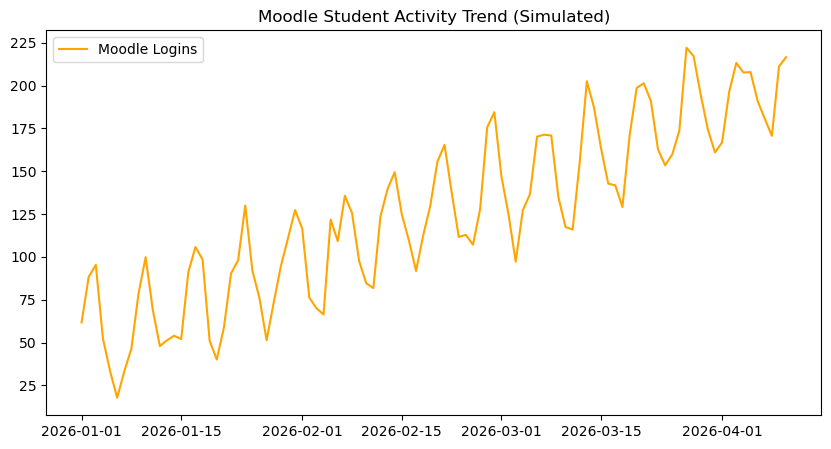

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a date range (100 days of Moodle logs)
dates = pd.date_range(start='2026-01-01', periods=100)

# 2. Simulate activity: A mix of a steady trend + weekly "humps" + some randomness
base_activity = np.linspace(50, 200, 100)  # Growing class size
weekly_cycle = 30 * np.sin(np.arange(100) * (2 * np.pi / 7))  # Weekend dips
noise = np.random.normal(0, 10, 100)  # Random daily variation

logins = base_activity + weekly_cycle + noise

# 3. Build the DataFrame
df_moodle = pd.DataFrame({'Date': dates, 'Daily_Logins': logins})
df_moodle.set_index('Date', inplace=True)
df_moodle.head()

# 4. Visualize the Trend
plt.figure(figsize=(10, 5))
plt.plot(df_moodle.index, df_moodle['Daily_Logins'], color='orange', label='Moodle Logins')
plt.title("Moodle Student Activity Trend (Simulated)")
plt.legend()
plt.show()

In [83]:
# Create "Shifted" columns (The AI's memory)
df_moodle['Day_Minus_1'] = df_moodle['Daily_Logins'].shift(1)
df_moodle['Day_Minus_2'] = df_moodle['Daily_Logins'].shift(2)
df_moodle['Day_Minus_3'] = df_moodle['Daily_Logins'].shift(3)

# Drop the empty rows created by the shifting
df_moodle.dropna(inplace=True)

# Features: Last 3 days | Target: Today's logins
X = df_moodle[['Day_Minus_1', 'Day_Minus_2', 'Day_Minus_3']]
y = df_moodle['Daily_Logins']

print("🧠 The AI can now see 3 days into the past to predict today!")
df_moodle.head()

🧠 The AI can now see 3 days into the past to predict today!


,Daily_Logins,Day_Minus_1,Day_Minus_2,Day_Minus_3
Date,,,,
2026-01-04,52.398155,95.331547,88.334997,61.748021
2026-01-05,33.388268,52.398155,95.331547,88.334997
2026-01-06,17.753585,33.388268,52.398155,95.331547
2026-01-07,33.135407,17.753585,33.388268,52.398155
2026-01-08,46.477051,33.135407,17.753585,33.388268


#### Training the Model Brain

✅ 'moodle_forecaster.json' is ready for your GUI!


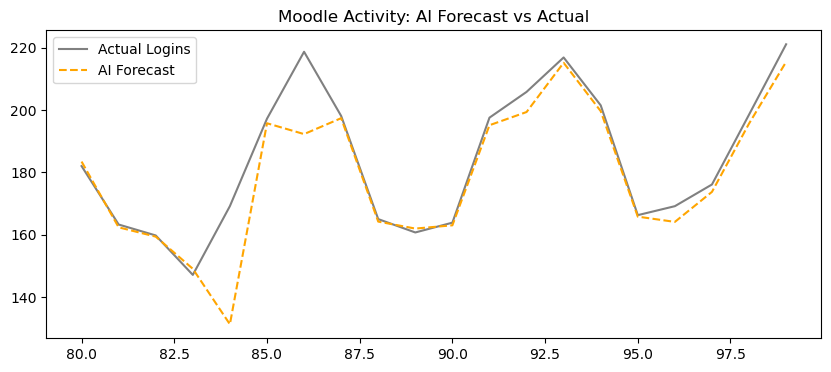

In [85]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Create 100 days of simulated Moodle logins
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=100)
# Trend: Slow growth + Weekly cycle (weekends are quiet) + Random noise
activity = np.linspace(50, 200, 100) + 30 * np.sin(np.arange(100) * (2 * np.pi / 7)) + np.random.normal(0, 10, 100)

df_moodle = pd.DataFrame({'Date': dates, 'Daily_Logins': activity})

# 2. CREATE THE "WINDOW" (Lagged Features)
# We give the AI the last 3 days to predict today
df_moodle['Day_1'] = df_moodle['Daily_Logins'].shift(1)
df_moodle['Day_2'] = df_moodle['Daily_Logins'].shift(2)
df_moodle['Day_3'] = df_moodle['Daily_Logins'].shift(3)
df_moodle.dropna(inplace=True)

# 3. Features (X) and Target (y)
X = df_moodle[['Day_1', 'Day_2', 'Day_3']]
y = df_moodle['Daily_Logins']

# 4. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Forecaster
moodle_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
moodle_model.fit(X_train, y_train)

# 6. Save the Brain
moodle_model.save_model("moodle_forecaster.json")
print("✅ 'moodle_forecaster.json' is ready for your GUI!")

# Visualize the Prediction
plt.figure(figsize=(10, 4))
plt.plot(df_moodle.index[-20:], y[-20:], label="Actual Logins", color="gray")
plt.plot(df_moodle.index[-20:], moodle_model.predict(X[-20:]), label="AI Forecast", color="orange", linestyle="--")
plt.title("Moodle Activity: AI Forecast vs Actual")
plt.legend()
plt.show()

### AI Moodle Exam Sample Data

In [30]:
import pandas as pd
import numpy as np

# 1. Create a "Filthy" Student Dataset
np.random.seed(42)
data_size = 200

data = {
    'Student_ID': range(1001, 1001 + data_size),
    'Hours_Studied': np.random.randint(1, 50, data_size).astype(float),
    'Attendance_Rate': np.random.randint(50, 100, data_size),
    'Previous_Grade': np.random.randint(40, 100, data_size),
    'Gender': np.random.choice(['M', 'F', 'male', 'female', 'F '], data_size), # Standardize this!
    'Exam_Score': np.random.normal(70, 15, data_size) # This is your TARGET (y)
}

df = pd.DataFrame(data)

# 2. Add some "Filth" for Step 01 practice
df.loc[10:15, 'Hours_Studied'] = np.nan  # Missing values to fix
df.loc[160:162, 'Exam_Score'] = 500      # Impossible Outliers to fix
df = pd.concat([df, df.iloc[[20, 21]]])  # Duplicates to drop

# 3. Save it to your computer
df.to_csv('moodle_exam_data.csv', index=False)
print("✅ 'moodle_exam_data.csv' has been created. Ready for Step 01!")

# 4. Exporting onto Desktop:
#df.to_csv(r'C:\Users\micha\OneDrive\Desktop\moodle_exam_data.csv', index=False)

✅ 'moodle_exam_data.csv' has been created. Ready for Step 01!


#### Checking Data Details

In [17]:
df.describe()

,Student_ID,Hours_Studied,Attendance_Rate,Previous_Grade,Exam_Score
count,202.000000,196.000000,202.000000,202.000000,202.000000
mean,1099.717822,25.147959,75.559406,70.420792,75.275458
std,58.121888,14.027210,14.549587,17.552371,54.368508
min,1001.000000,1.000000,50.000000,40.000000,32.925332
25%,1049.250000,13.750000,65.250000,55.000000,58.217959
50%,1099.500000,26.000000,77.000000,70.000000,69.113299
75%,1149.750000,37.250000,86.750000,86.000000,79.454483
max,1200.000000,49.000000,99.000000,99.000000,500.000000


#### Cleaning The Data

In [31]:
# 1. moodle_exam_data
df = pd.DataFrame(data)

# 2. Standardize Gender (so 'F' and 'female' become the same)
df['Gender'] = df['Gender'].str.lower().str.strip()
df['Gender'] = df['Gender'].replace({'f': 'female', 'm': 'male'})

# 3. The "Mean" logic
clean_mean = df[df['Hours_Studied'] < 49]['Hours_Studied'].mean()
df.loc[df['Hours_Studied'] > 49, 'Hours_Studied'] = clean_mean
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())

# 4. Fixing the impossible 500 scores to a realistic cap (100) or the median
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100

# 5. DROPING DUPLICATES 
df = df.drop_duplicates()

#df.to_csv(r'C:\Users\micha\OneDrive\Desktop\finished_exam_data.csv', index=False)

#### Identify & isolate the target

In [33]:
# STEP 02: Identify & isolate the target (y)
# Features (X) = The 'Clues'
# Target (y) = The 'Answer' we want to predict

X = df[['Hours_Studied', 'Attendance_Rate', 'Previous_Grade']]
y = df['Exam_Score']

print("🎯 Target isolated! We are using 3 clues to predict the Exam Score.")

🎯 Target isolated! We are using 3 clues to predict the Exam Score.


#### Spliting the Data

In [34]:
from sklearn.model_selection import train_test_split

# STEP 03: Split the data (The "80/20" Rule)
# We use the X and y you created in Step 02
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Success! X_train and X_test are now defined.")
print(f"We have {len(X_train)} students to train on and {len(X_test)} to test.")

✅ Success! X_train and X_test are now defined.
We have 160 students to train on and 40 to test.


#### Algorithm Selection 

In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Initialize the Weapon (using your random_state=42)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Train the Brain (The "Study" Phase)
model.fit(X_train, y_train)

# 3. Test the Brain (The "Exam" Phase)
predictions = model.predict(X_test)

# 4. Check the Score (How far off are we?)
mae = mean_absolute_error(y_test, predictions)

print(f"📊 Mean Absolute Error: {mae:.2f}")
print("This means on average, our AI is only off by about " + str(round(mae, 2)) + " points!")

📊 Mean Absolute Error: 14.41
This means on average, our AI is only off by about 14.41 points!


#### Training the Model

In [36]:
from xgboost import XGBRegressor

# Step 05: Train the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print("🎯 The Brain is trained!")

🎯 The Brain is trained!


#### Testing the Model

In [37]:
from sklearn.metrics import mean_absolute_error

# 1. Ask the AI to predict scores for the students it HASN'T seen (X_test)
predictions = model.predict(X_test)

# 2. Compare the AI's guesses to the actual scores (y_test)
mae = mean_absolute_error(y_test, predictions)

print(f"📊 The Report Card is in! MAE: {mae:.2f}")
print(f"This means on average, the AI is off by only {mae:.2f} points.")

📊 The Report Card is in! MAE: 14.41
This means on average, the AI is off by only 14.41 points.


#### Transferring & Saving the Codes on PyCharm

In [38]:
# Save the model as a portable .json file
model.save_model('student_exam_predictor.json')

print("💾 'student_exam_predictor.json' has been saved to your folder!")
print("The 'Brain' is now a portable asset.")

💾 'student_exam_predictor.json' has been saved to your folder!
The 'Brain' is now a portable asset.


#### Block of Codes To Save in PyCharm

In [ ]:
# Saving the assembled Codes onto PyCharm for future Use:

import pymysql
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# --- STEP 01: PULL FROM WAREHOUSE ---
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='apprendre22',
    database='mydb'
)
df = pd.read_sql("SELECT * FROM moodle_exam_data", connection)
connection.close()

# --- STEP 01.5: THE CLEANING (Essential!) ---
# 1. Standardize Gender
df['Gender'] = df['Gender'].astype(str).str.lower().str.strip()
# 2. Fix the 500 Outliers in Exam_Score
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100
# 3. Handle Missing Hours
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())
# 4. Final Sweep
df = df.drop_duplicates()

# --- STEP 02: ISOLATE TARGET ---
X = df[['Hours_Studied', 'Attendance_Rate', 'Previous_Grade']]
y = df['Exam_Score']

# --- STEP 03: THE SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 04/05: TRAIN THE BRAIN ---
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- STEP 06: TEST & EVALUATE ---
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"✅ Model Trained. Mean Absolute Error: {mae:.2f}")

# --- STEP 07: SAVE THE BRAIN (The Payload) ---
model.save_model('student_exam_predictor.json')
print("💾 'student_exam_predictor.json' created successfully!")

In [ ]:
# Create a dictionary of Feature Importances
importance = model.get_booster().get_score(importance_type='weight')

# Sort them to see the 'MVP' at the top
sorted_importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

print("🏆 Feature Importance Rankings:")
for feature, score in sorted_importance.items():
    print(f"{feature}: {score}")


In [ ]:
import pymysql
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# --- STEP 01: PULL FROM WAREHOUSE ---
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='apprendre22',
    database='mydb'
)
df = pd.read_sql("SELECT * FROM moodle_exam_data", connection)
connection.close()

# --- STEP 01.5: THE CLEANING (Essential!) ---
# 1. Standardize Gender
df['Gender'] = df['Gender'].astype(str).str.lower().str.strip()
# 2. Fix the 500 Outliers in Exam_Score
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100
# 3. Handle Missing Hours
df['Hours_Studied'] = df['Hours_Studied'].fillna(df['Hours_Studied'].median())
# 4. Final Sweep
df = df.drop_duplicates()

# --- STEP 02: ISOLATE TARGET ---
X = df[['Hours_Studied', 'Attendance_Rate', 'Previous_Grade']]
y = df['Exam_Score']

# --- STEP 03: THE SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 04/05: TRAIN THE BRAIN ---
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- STEP 06: TEST & EVALUATE ---
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print(f"✅ Model Trained. Mean Absolute Error: {mae:.2f}")

# --- STEP 07: SAVE THE BRAIN (The Payload) ---
model.save_model('student_exam_predictor.json')
print("💾 'student_exam_predictor.json' created successfully!")

In [ ]:
# XGBoost: eXtreme Gradient Boosting; good for supervised learning problems

# Step 1. Explore & Prep Data
# Step 2. Buil a pipeline of training
# Step 3. Set up a Hyperparameter Tuning
# Step 4. Train the XGBoost Modle
# Step 5. Evaluate hte Model and make Predictions
# Step 6. Measure the Feature Importance (Optional)

In [ ]:
# Model Data Integration Process:
# To import the new data into MySQL Workbench
# To clean & convert the data to match previous data:
# (CONVERTING Date format; new data "Audit" query; & "ML-Ready" Export)
# To Export the data into Pycharm Data folder
# To perform Data Integration in to existing model by:
# The "Stitch" (train_moodle_model.py) by updating the following sections:
    # Load the new CSVs.
    # Assign them new IDs (e.g., Course_ID = 3 and Course_ID = 4).
    # Add them to the pd.concat([...]) list.
#The UI (app.py):
    # Add the new course names to the st.sidebar.selectbox options.
    # Update the if/elif logic so "Course 4" sends the number 3 to the model.
# run this in PyCharm terminal: python train_moodle_model.py
# and finish with: streamlit run app.py



In [ ]:
# New Course / Data Scince_Python:
# https://www.youtube.com/watch?v=HrRA67O-QXI
# Learn Python AND Data Science in just an hour
# Also at: https://www.w3schools.com/